In [ ]:
# filepath: 
import os
import random
import json
import numpy as np
import pandas as pd
import networkx as nx
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import List, Dict, Tuple

# ==========================================
# 0. 工具函数：加载预算配置
# ==========================================
def load_budget_config(csv_path: str, method_name: str = "FOIS_nrs") -> Dict[str, int]:
    """
    从 results_summary CSV 文件中加载每个查询的 budget (n_post)。
    Key: query_basename, Value: n_post
    """
    if not os.path.exists(csv_path):
        print(f"[Warn] Budget CSV not found: {csv_path}")
        return {}
    
    try:
        df = pd.read_csv(csv_path)
        # 筛选指定 method
        target_df = df[df['method'] == method_name]
        
        # 构建字典: query_basename -> n_post
        # 如果有重复，取第一个或平均（这里取最大值以保证充足预算，或者取第一个）
        budget_map = {}
        grouped = target_df.groupby('query_basename')['n_post'].max()
        budget_map = grouped.to_dict()
        
        print(f"[Config] Loaded budgets for {len(budget_map)} queries from {csv_path} (method={method_name}).")
        return budget_map
    except Exception as e:
        print(f"[Error] Failed to load budget CSV: {e}")
        return {}

# ==========================================
# 1. 基础类定义 (DataGraph 优化版)
# ==========================================
class DataGraph:
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)
        self.labels = {}
        self.nodes_by_label = collections.defaultdict(list)
        # 优化索引: adj_label[u][target_label] -> [v1, v2...]
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        
        print(f"[DataGraph] Reading raw file: {filepath}")
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid, lbl = int(parts[1]), int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                elif parts[0] == 'e':
                    u, v = int(parts[1]), int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        
        print("[DataGraph] Building label indices (Progress bar)...")
        # 使用 tqdm 显示进度
        for u, neighbors in tqdm(self.adj.items(), desc="Indexing Edges"):
            for v in neighbors:
                if v in self.labels:
                    self.adj_by_label[u][self.labels[v]].append(v)
        print("[DataGraph] Ready.")

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        return self.adj_by_label[u].get(label, [])

class PatternGraph:
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    self.G.add_node(int(parts[1]), label=int(parts[2]))
                elif parts[0] == 'e':
                    self.G.add_edge(int(parts[1]), int(parts[2]))
    @property
    def nodes(self): return self.G.nodes
    def neighbors(self, u): return self.G.neighbors(u)
    def number_of_nodes(self): return self.G.number_of_nodes()

# ==========================================
# 2. OracleManager (优化版，向量化加载)
# ==========================================
class OracleManager:
    def __init__(self, dataset_path: str, 
                 oracle_col: str = "ML1_oracle1_probability", 
                 proxy_col: str = "ML1_proxy4b1_probability"):
        self.id_type_map = {}
        self.oracle_probs = {} 
        self.proxy_probs = {}  
        self.load_data(dataset_path, oracle_col, proxy_col)

    def load_data(self, dataset_path, oracle_col, proxy_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        print("[OracleManager] Loading ID Mapping...")
        # 1. 加载 ID 映射 (只保留 Post 类型)
        map_df = pd.read_csv(idmap_path, dtype={'internal_id': int, 'orig_id': str, 'type': str}, usecols=['internal_id', 'orig_id', 'type'])
        
        # 保存 type map
        self.id_type_map = dict(zip(map_df['internal_id'], map_df['type']))
        
        # 只保留 Post 类型的映射用于合并
        post_map_df = map_df[map_df['type'] == 'Post'][['internal_id', 'orig_id']]

        print("[OracleManager] Loading Post Data (Vectorized)...")
        try:
            # 2. 加载 Post 数据
            header = pd.read_csv(post_path, nrows=0)
            id_col = 'id:ID' if 'id:ID' in header.columns else header.columns[0]
            
            # 读取
            post_df = pd.read_csv(post_path, usecols=[id_col, oracle_col, proxy_col], dtype={id_col: str})
            
            # 3. 使用 Merge 代替循环
            print("[OracleManager] Merging Data...")
            merged = pd.merge(post_map_df, post_df, left_on='orig_id', right_on=id_col, how='left')
            
            # 4. 填充 NaN 并转换为字典
            merged[oracle_col] = pd.to_numeric(merged[oracle_col], errors='coerce').fillna(0.0)
            merged[proxy_col] = pd.to_numeric(merged[proxy_col], errors='coerce').fillna(0.0)
            
            self.oracle_probs = dict(zip(merged['internal_id'], merged[oracle_col]))
            self.proxy_probs = dict(zip(merged['internal_id'], merged[proxy_col]))
            
            print(f"[OracleManager] Loaded {len(self.oracle_probs)} probabilities.")
            
        except Exception as e:
            print(f"[Error] Failed to load post.csv: {e}")

    def check_oracle(self, internal_id: int, threshold: float = 0.5) -> bool:
        if internal_id not in self.oracle_probs:
            return self.id_type_map.get(internal_id) != 'Post'
        return self.oracle_probs[internal_id] > threshold

    def get_proxy_prob(self, internal_id: int) -> float:
        return self.proxy_probs.get(internal_id, 0.0)

# ==========================================
# 3. 修改后的 WanderJoinSampler
# ==========================================
class WanderJoinSampler:
    # 定义需要重要性采样的标签 (Post)
    POST_LABEL = 1 

    def __init__(self, data_graph, query_graph, oracle_manager):
        self.G = data_graph
        self.Q = query_graph
        self.oracle_manager = oracle_manager
        self.id_type_map = oracle_manager.id_type_map
        
        # --- 优化：预计算 Post 节点的全局采样分布 ---
        self.post_nodes = np.array(self.G.nodes_by_label.get(self.POST_LABEL, []))
        
        self.post_weights = None
        self.post_probs = None
        self.post_total_weight = 0.0
        
        if len(self.post_nodes) > 0:
            print(f"[Sampler] Pre-calculating weights for {len(self.post_nodes)} Post nodes...")
            # 2. 批量获取权重 + 防0平滑 epsilon
            probs = np.array([self.oracle_manager.get_proxy_prob(uid) for uid in self.post_nodes])
            self.post_weights = np.sqrt(probs + 1e-9) 
            
            # 3. 计算归一化概率分布
            self.post_total_weight = np.sum(self.post_weights)
            
            if self.post_total_weight > 0:
                self.post_probs = self.post_weights / self.post_total_weight
            else:
                self.post_probs = np.ones(len(self.post_nodes)) / len(self.post_nodes)
            print("[Sampler] Pre-calculation done.")

    def get_matching_order(self) -> List[int]:
        start_node = 0
        order = []
        visited = set()
        queue = [start_node]
        visited.add(start_node)
        while queue:
            u = queue.pop(0)
            order.append(u)
            for v in sorted(self.Q.neighbors(u)):
                if v not in visited:
                    visited.add(v)
                    queue.append(v)
        return order

    def get_node_weight(self, node_id: int) -> float:
        prob = self.oracle_manager.get_proxy_prob(node_id)
        # 加一个极小的 epsilon，保证即使 proxy=0 也有机会被选中
        return np.sqrt(prob + 1e-9) 

    def single_walk(self, order: List[int], mode: str = 'uniform') -> Tuple[float, bool, Dict[int, int]]:
        mapping = {}
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            # --- 1. 获取候选集 ---
            candidates = []
            is_start_node = (i == 0)
            
            if is_start_node and target_label == self.POST_LABEL:
                candidates = self.post_nodes # numpy array
            elif is_start_node:
                candidates = self.G.nodes_by_label.get(target_label, [])
            else:
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                possible_v = None
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    if possible_v is None: possible_v = neighbors_subset
                    else: possible_v &= neighbors_subset
                    if not possible_v: break
                
                if possible_v: possible_v -= used_data_nodes
                candidates = list(possible_v) if possible_v else []

            if len(candidates) == 0:
                return 0.0, False, {}

            # --- 2. 采样逻辑 ---
            if mode == 'importance' and target_label == self.POST_LABEL:
                # 情况 A: 起点且有预计算分布
                if is_start_node and self.post_probs is not None:
                    idx = np.random.choice(len(self.post_nodes), p=self.post_probs)
                    v_selected = self.post_nodes[idx]
                    prob_selected = self.post_probs[idx]
                    
                    if prob_selected > 0:
                        walk_weight *= (1.0 / prob_selected)
                    else:
                        return 0.0, False, {}
                        
                # 情况 B: 中间节点或无预计算
                else:
                    c_arr = np.array(candidates) if not isinstance(candidates, np.ndarray) else candidates
                    weights = np.array([self.get_node_weight(v) for v in c_arr])
                    total_weight = np.sum(weights)
                    
                    if total_weight <= 1e-12: # 退化为均匀
                        idx = np.random.choice(len(c_arr))
                        v_selected = c_arr[idx]
                        walk_weight *= len(c_arr)
                    else:
                        probs = weights / total_weight
                        idx = np.random.choice(len(c_arr), p=probs)
                        v_selected = c_arr[idx]
                        walk_weight *= (total_weight / weights[idx])
                
            else:
                # 均匀采样逻辑
                if isinstance(candidates, np.ndarray):
                    v_selected = np.random.choice(candidates)
                else:
                    v_selected = random.choice(candidates)
                walk_weight *= len(candidates)

            mapping[q_u] = v_selected
            used_data_nodes.add(v_selected)
                
        return walk_weight, True, mapping

    def check_oracle(self, mapping):
        for d_node in mapping.values():
            if not self.oracle_manager.check_oracle(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, unique_post_budget: int = 1000, mode: str = 'uniform', max_trials: int = 40000):
        """
        Oracle 预算感知的估计。
        采样直到消耗的 Unique Post Oracle 次数达到 unique_post_budget。
        重复采样的 Post 不消耗预算。
        """
        order = self.get_matching_order()
        
        # 记录所有的 walk weights (包括那些不消耗预算的重复 walk)
        walk_estimates = []
        
        # 记录不重复的 Post 节点 (Oracle Budget)
        unique_post_nodes_seen = set()
        
        trials = 0
        
        # 循环直到 Unique 预算耗尽 或 达到最大尝试次数防止死循环
        with tqdm(total=unique_post_budget, desc=f"Wander({mode})", leave=False) as pbar:
            while len(unique_post_nodes_seen) < unique_post_budget and trials < max_trials:
                trials += 1
                
                weight, struct_success, mapping = self.single_walk(order, mode=mode)
                
                # Check 1: 结构匹配是否成功
                if not struct_success:
                    # 这是一次失败的 walk (死路)，权重为 0
                    walk_estimates.append(0.0)
                    continue
                
                # Check 2: Oracle 检查
                # 注意：这里我们模拟“有缓存”的 Oracle。
                # 即使之前见过这个 Post，我们依然要进行这次 Oracle 判定（因为是查缓存免费）
                # 我们依然要算这次 sample 的 value。
                
                # 收集本次 walk 涉及到的 post 节点
                current_walk_posts = set()
                for node_id in mapping.values():
                    if self.id_type_map.get(node_id) == 'Post':
                        current_walk_posts.add(node_id)
                
                # 更新预算消耗
                new_posts = current_walk_posts - unique_post_nodes_seen
                if new_posts:
                    count_new = len(new_posts)
                    # 只有当我们能在 budget 内“支付”这些新 post 时，才算这次 walk
                    # 这是一个严谨的边界处理：如果这次 walk 带来了 5 个新 post，但 budget 只剩 1 个，
                    # 严格来说我们不应该执行这次 walk。
                    # 但为了简化，只要 budget 没满，就执行，超出一点点无所谓 (或者在这里 break)
                    if len(unique_post_nodes_seen) >= unique_post_budget:
                        # 预算已满，放弃这次 walk (虽然有点可惜，但为了对齐 budget)
                        break 
                    
                    unique_post_nodes_seen.update(new_posts)
                    pbar.update(len(unique_post_nodes_seen) - pbar.n)
                
                # Oracle 判定
                oracle_pass = self.check_oracle(mapping)
                if oracle_pass:
                    walk_estimates.append(weight)
                else:
                    walk_estimates.append(0.0)
        
        if len(walk_estimates) == 0:
            return {"T_hat": 0.0, "success_rate": 0.0, "n_post": 0, "trials": 0}

        mean_est = np.mean(walk_estimates)
        success_valid_rate = np.count_nonzero(walk_estimates) / len(walk_estimates)
        
        return {
            "T_hat": mean_est,
            "success_rate": success_valid_rate,
            "n_post": len(unique_post_nodes_seen),
            "trials": len(walk_estimates) 
        }
   
# ==========================================
# 5. 批处理函数 (Batch Processing)
# ==========================================
# ...existing code...
# ==========================================
# 5. 批处理函数 (Batch Processing)
# ==========================================
def batch_evaluate(dataset_name="dataset_one", methods=['uniform']): # <--- 修改这里可以自定义运行的方法
    # --- 1. 路径配置 ---
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    true_file = os.path.join(base_path, "ground_truth/T_true_ML1_oracle1_probability.txt") 
    
    # 预算CSV路径
    budget_csv_path = os.path.join(base_path, "results/result_summarys/ML1_proxy4b_probability/results_summary_run_1.csv")
    
    output_csv = f"wanderjoin_comparison_{dataset_name}.csv"

    # --- 2. 加载静态资源 ---
    print(f"====== Batch Evaluation: {dataset_name} ======")
    print(f"====== Methods to run: {methods} ======")
    
    # 加载预算
    budget_map = load_budget_config(budget_csv_path, method_name="FOIS_nrs")
    if not budget_map:
        print("[Warning] No budget map loaded. Will use default budget = 1000.")

    print(">>> 1. Loading Data Graph...")
    if not os.path.exists(data_graph_file):
        print(f"[Error] Data graph not found: {data_graph_file}")
        return None
    DG = DataGraph(data_graph_file)
    
    print(">>> 2. Loading Oracle Manager...")
    oracle = OracleManager(base_path, oracle_col="ML1_oracle1_probability", proxy_col="ML1_proxy4b1_probability")
    
    print(f">>> 3. Loading Ground Truth from {true_file}...")
    try:
        with open(true_file, 'r') as f:
            true_vals = json.load(f)
    except Exception as e:
        print(f"[Error] JSON load failed: {e}")
        return None

    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    print(f">>> Found {len(query_files)} queries. Starting comparison...")
    
    records = []

    # --- 3. 循环评估 ---
    for q_file in tqdm(query_files, desc="Evaluating"):
        
        # 获取 T_true
        if q_file in true_vals:
            T_true = float(true_vals[q_file])
        elif q_file.replace(".graph", "") in true_vals:
            T_true = float(true_vals[q_file.replace(".graph", "")])
        else:
            continue
        if T_true == 0: continue 
        
        # 获取预算
        basename = q_file.replace(".graph", ".graph")
        # 如果找不到配置，默认给 1000
        budget = int(budget_map.get(basename, 1000))
        budget = max(10, budget)
        print(f"\n[Query: {basename}] Target Unique Post Budget: {budget}")

        q_path = os.path.join(query_dir, q_file)
        
        try:
            QG = PatternGraph(q_path)
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # --- 动态执行配置的方法 ---
            
            # 方法 A: 均匀采样 (Uniform)
            if 'uniform' in methods:
                res_u = sampler.estimate(budget, mode='uniform')
                est_u = res_u['T_hat']
                err_u = (est_u - T_true) / T_true
                abs_err_u = abs(err_u)
                
                records.append({
                    "query_basename": q_file,
                    "method": "Uniform",
                    "T_true": T_true,
                    "T_hat": est_u,
                    "Qerror": err_u,
                    "AbsRelativeError": abs_err_u,
                    "SuccessRate": res_u['success_rate'],
                    "n_post": res_u['n_post'],
                    "trials": res_u['trials']
                })
                print(f"[Query: {basename}] UNIFORM -> T_hat: {est_u:.2f} | T_true: {T_true:.2f} | Error: {abs_err_u:.4f}")
            
            # 方法 B: 重要性采样 (Importance)
            if 'importance' in methods:
                res_i = sampler.estimate(budget, mode='importance')
                est_i = res_i['T_hat']
                err_i = (est_i - T_true) / T_true
                abs_err_i = abs(err_i)
                
                records.append({
                    "query_basename": q_file,
                    "method": "Importance",
                    "T_true": T_true,
                    "T_hat": est_i,
                    "Qerror": err_i,
                    "AbsRelativeError": abs_err_i,
                    "SuccessRate": res_i['success_rate'],
                    "n_post": res_i['n_post'],
                    "trials": res_i['trials']
                })
                print(f"[Query: {basename}] IMPORTANCE -> T_hat: {est_i:.2f} | T_true: {T_true:.2f} | Error: {abs_err_i:.4f}")
            
        except Exception as e:
            print(f"[Warn] Failed on {q_file}: {e}")

    # --- 4. 保存结果 ---
    df = pd.DataFrame(records)
    if not df.empty:
        df.to_csv(output_csv, index=False)
        print(f"\n>>> Results saved to {output_csv}")
        plot_results(df)
        return df
    else:
        print("No results generated.")
        return None
# ...existing code...

# ==========================================
# 6. 绘图函数 (保持原样，略微适配)
# ==========================================
def plot_results(df, allowed_range=(-2.0, 2.0), max_labels_per_method=10):
    if df is None or df.empty: return
    import seaborn as sns

    # 1) Relative Error Boxplot
    plt.figure(figsize=(10, 6))
    methods = list(df['method'].unique())
    sns.boxplot(x="method", y="Qerror", data=df, order=methods,
                     showfliers=False, width=0.5, palette="Set2")
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title("Relative Error (Fixed Unique Post Budget)")
    plt.ylabel("(Est - True) / True")
    plt.ylim(allowed_range) # 限制显示范围
    plt.tight_layout()
    plt.show()

    # 2) Efficiency: Trials per Budget
    # 展示有多少“免费”的重复采样被利用了
    plt.figure(figsize=(8, 5))
    df['Efficiency'] = df['trials'] / df['n_post']
    sns.barplot(x="method", y="Efficiency", data=df, palette="Reds_d")
    plt.title("Sampling Efficiency (Total Trials / Unique Post Cost)")
    plt.ylabel("Ratio (Higher is Better)")
    plt.tight_layout()
    plt.show()

    print("\n====== Statistical Summary ======")
    print(df.groupby("method")[["Qerror", "n_post", "trials"]].mean())

# ==========================================
# 执行入口 (示例)
# ==========================================
# df_res = batch_evaluate("dataset_test2") 

====== Batch Evaluation: dataset_three ======
====== Methods to run: ['uniform', 'importance'] ======
[Config] Loaded budgets for 246 queries from /home/wangshuo/resource/datasets/parler_data/dataset_three/results/result_summarys/ML1_proxy4b_probability/results_summary_run_1.csv (method=FOIS_nrs).
>>> 1. Loading Data Graph...
[DataGraph] Reading raw file: /home/wangshuo/resource/datasets/parler_data/dataset_three/data_graph/parler.graph
[DataGraph] Building label indices (Progress bar)...


Indexing Edges: 100%|██████████| 192668/192668 [00:02<00:00, 88217.98it/s] 


[DataGraph] Ready.
>>> 2. Loading Oracle Manager...
[OracleManager] Loading ID Mapping...
[OracleManager] Loading Post Data (Vectorized)...
[OracleManager] Merging Data...
[OracleManager] Loaded 24082 probabilities.
>>> 3. Loading Ground Truth from /home/wangshuo/resource/datasets/parler_data/dataset_three/ground_truth/T_true_ML1_oracle1_probability.txt...
>>> Found 246 queries. Starting comparison...


Evaluating:   0%|          | 0/246 [00:00<?, ?it/s]


[Query: query_cycle_4_0.graph] Target Unique Post Budget: 416
[Sampler] Pre-calculating weights for 24082 Post nodes...
[Sampler] Pre-calculation done.


...

Evaluating: 100%|█████████▉| 245/246 [09:26<00:05,  5.44s/it]

[Query: query_star_4_9.graph] IMPORTANCE -> T_hat: 4187.07 | T_true: 5560.00 | Error: 0.2469

[Query: query_tree_6_6.graph] Target Unique Post Budget: 313
[Sampler] Pre-calculating weights for 24082 Post nodes...
[Sampler] Pre-calculation done.


[Query: query_tree_6_6.graph] UNIFORM -> T_hat: 573861.31 | T_true: 1972000.00 | Error: 0.7090


Evaluating: 100%|██████████| 246/246 [09:30<00:00,  2.32s/it]
/tmp/ipykernel_3810521/682416393.py:511: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="Qerror", data=df, order=methods,


[Query: query_tree_6_6.graph] IMPORTANCE -> T_hat: 556248.76 | T_true: 1972000.00 | Error: 0.7179

>>> Results saved to wanderjoin_comparison_dataset_three.csv


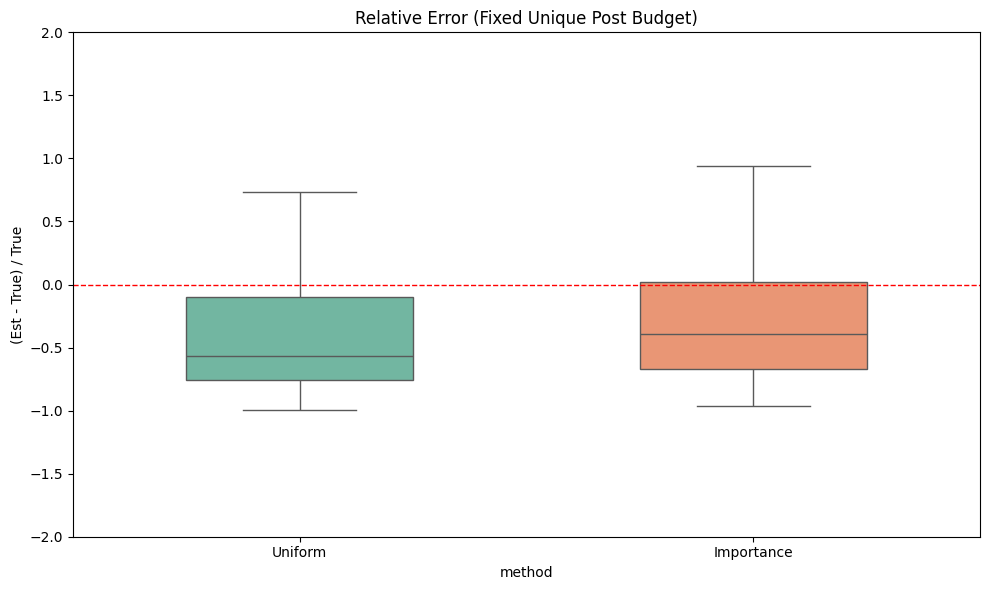

/tmp/ipykernel_3810521/682416393.py:524: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="method", y="Efficiency", data=df, palette="Reds_d")


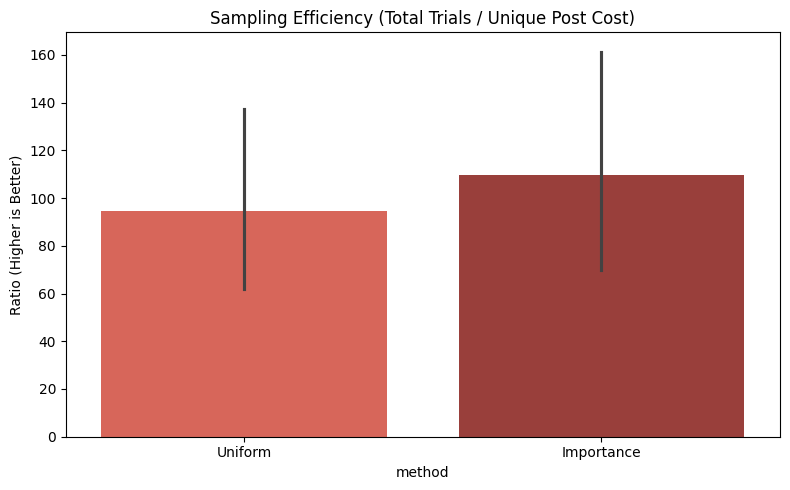


====== Statistical Summary ======
              Qerror      n_post        trials
method                                        
Importance -0.096175  304.235772  12151.910569
Uniform     0.362312  304.369919  11724.971545


In [13]:
df_res = batch_evaluate("dataset_three", methods=['uniform', 'importance'])

>>> 已加载数据，共 492 行记录。
>>> 评估方法: ['Uniform' 'Importance']

误差值统计摘要 (Relative Error Summary)
            Qerror         AbsRelativeError                     n_post  \
              mean     std             mean  median      max      mean   
method                                                                   
Importance -0.0962  1.1648           0.6858  0.5543  11.5302  304.2358   
Uniform     0.3623  5.6613           1.3118  0.6828  80.7358  304.3699   

           SuccessRate  
                  mean  
method                  
Importance      0.0292  
Uniform         0.0190  


/tmp/ipykernel_3810521/4294004278.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="Qerror", data=df, palette="Set2", showfliers=False)
/tmp/ipykernel_3810521/4294004278.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="method", y="AbsRelativeError", data=df, palette="Set3", showfliers=False)


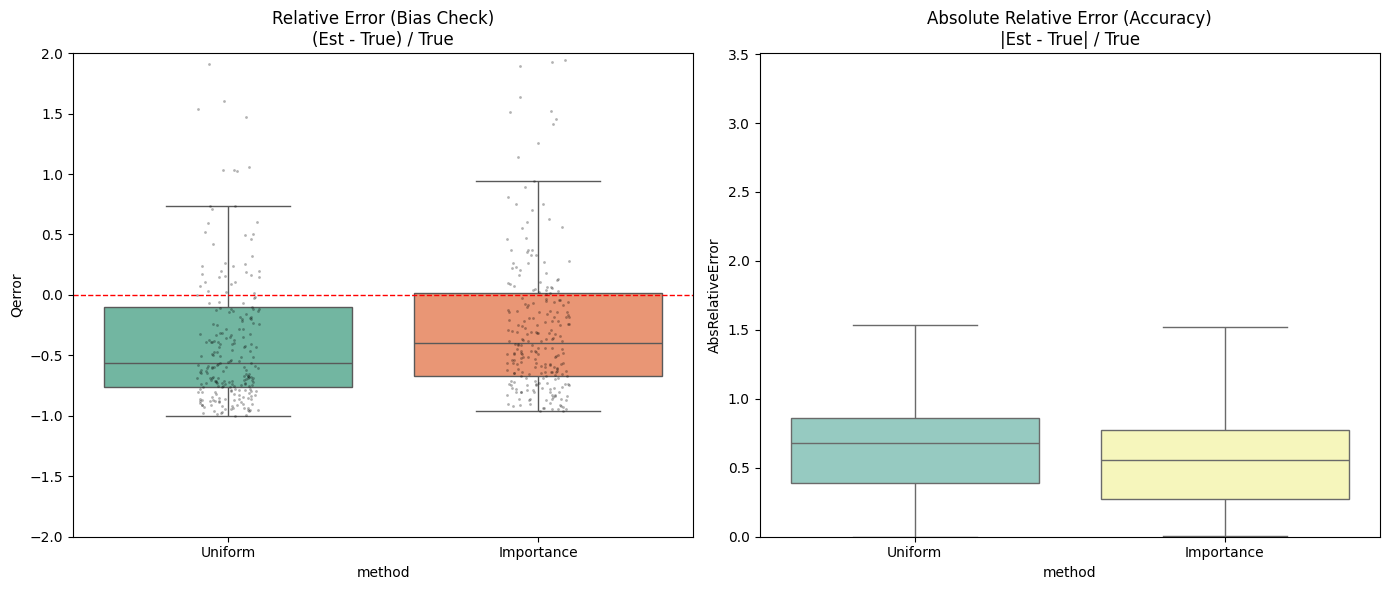

/tmp/ipykernel_3810521/4294004278.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="method", y=col_sr, data=df, palette="Pastel1")


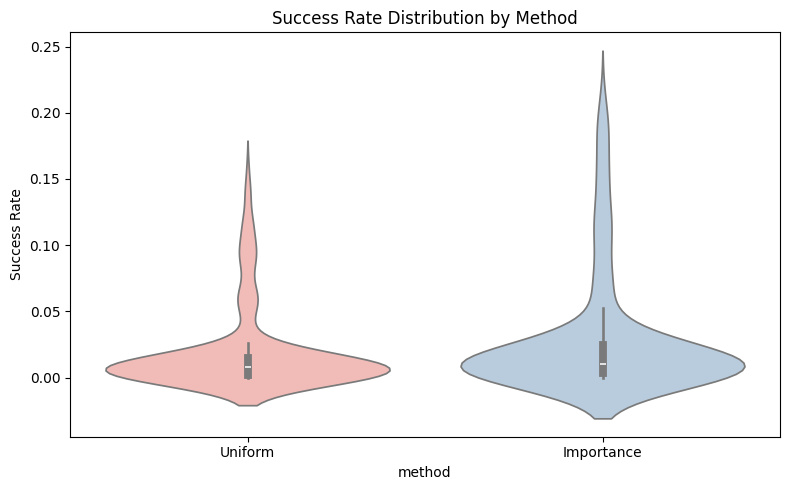

/tmp/ipykernel_3810521/4294004278.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="method", y="Efficiency", data=df, palette="Reds_d")


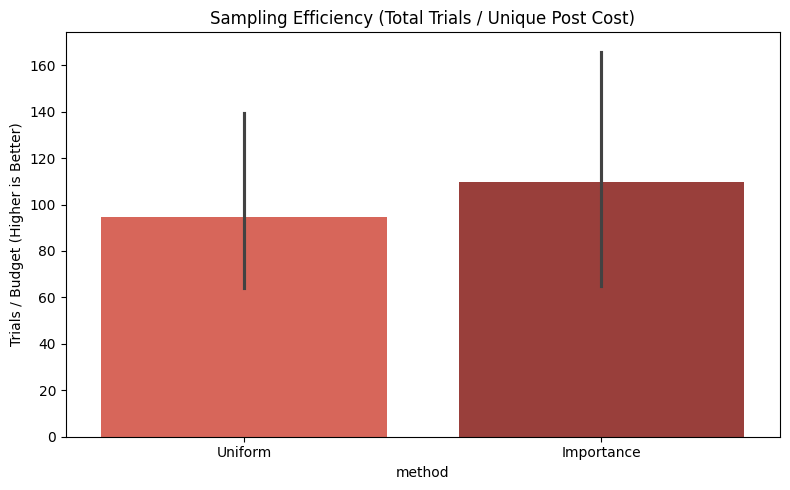


[Done] 统计分析完成。


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- 1. 加载数据 ---
csv_path = Path("/home/wangshuo/projects/Neo4j_Exp/pythonProject/src/baseline/wanderjoin_comparison_dataset_three.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)

# --- 自动兼容列名大小写 ---
# 检查到底是 "SuccessRate" 还是 "success_rate"
if "SuccessRate" in df.columns:
    col_sr = "SuccessRate"
elif "success_rate" in df.columns:
    col_sr = "success_rate"
else:
    # 如果都没有，创建一个全为 NaN 的列防止程序崩溃
    print("[Warn] Column 'SuccessRate' not found in CSV.")
    df['SuccessRate'] = np.nan
    col_sr = "SuccessRate"

# --- 2. 核心指标计算 ---
# 如果 CSV 里还没有计算 AbsRelativeError，这里补一下
if 'AbsRelativeError' not in df.columns:
    df['AbsRelativeError'] = df['Qerror'].abs()

# 计算效率指标
df['Efficiency'] = df['trials'] / df['n_post'].replace(0, np.nan)

print(f">>> 已加载数据，共 {len(df)} 行记录。")
print(f">>> 评估方法: {df['method'].unique()}")

# --- 3. 统计摘要输出 ---
print("\n" + "="*50)
print("误差值统计摘要 (Relative Error Summary)")
print("="*50)
# 使用动态确定的列名 col_sr
error_summary = df.groupby("method").agg({
    'Qerror': ['mean', 'std'],
    'AbsRelativeError': ['mean', 'median', 'max'],
    'n_post': ['mean'],
    col_sr: ['mean']
}).round(4)
print(error_summary)
print("="*50)

# --- 4. 绘图：相对误差对比 ---
plt.figure(figsize=(14, 6))

# 左图：Qerror (看偏差方向)
plt.subplot(1, 2, 1)
sns.boxplot(x="method", y="Qerror", data=df, palette="Set2", showfliers=False)
sns.stripplot(x="method", y="Qerror", data=df, color="black", size=2, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Relative Error (Bias Check)\n(Est - True) / True")
plt.ylim(-2, 2) 

# 右图：AbsRelativeError (看准确度)
plt.subplot(1, 2, 2)
# 自动设置 y 轴上限，排除极端离群值干扰可视化
upper_limit = df['AbsRelativeError'].quantile(0.95) * 1.5
sns.boxplot(x="method", y="AbsRelativeError", data=df, palette="Set3", showfliers=False)
plt.ylim(0, max(0.5, upper_limit)) # 至少显示到 0.5
plt.title("Absolute Relative Error (Accuracy)\n|Est - True| / True")

plt.tight_layout()
plt.show()

# --- 5. 绘图：成功率分布 ---
plt.figure(figsize=(8, 5))
sns.violinplot(x="method", y=col_sr, data=df, palette="Pastel1")
plt.title("Success Rate Distribution by Method")
plt.ylabel("Success Rate")
plt.tight_layout()
plt.show()

# --- 6. 绘图：采样效率 ---
plt.figure(figsize=(8, 5))
sns.barplot(x="method", y="Efficiency", data=df, palette="Reds_d")
plt.title("Sampling Efficiency (Total Trials / Unique Post Cost)")
plt.ylabel("Trials / Budget (Higher is Better)")
plt.tight_layout()
plt.show()

print(f"\n[Done] 统计分析完成。")